In [1]:
# Install required library
!pip install yfinance

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Download Apple stock data (last 5 years)
print("Downloading Apple stock data...")

ticker = "AAPL"  # Apple stock symbol
start_date = "2019-01-01"
end_date = "2024-01-01"

# Download data
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Downloaded {len(df)} trading days of data")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

/tmp/ipykernel_723/1197088794.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


✅ Downloaded 1258 trading days of data

Dataset shape: (1258, 5)

First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2019-01-02  37.469204  37.689864  36.593688  36.750285  148158800
2019-01-03  33.737000  34.574552  33.691918  34.161706  365248800
2019-01-04  35.177197  35.246006  34.118988  34.292192  234428400
2019-01-07  35.098900  35.312442  34.617248  35.281596  219111200
2019-01-08  35.767990  36.021867  35.238886  35.485642  164101200

Column names:
[('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


In [5]:
# Basic statistics
print("Dataset Information:")
print("=" * 50)
print(f"Total records: {len(df)}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"Number of years: {(df.index[-1] - df.index[0]).days / 365:.1f}")

print(f"\nPrice Statistics:")
print(f"Lowest price: ${df['Close'].min():.2f}")
print(f"Highest price: ${df['Close'].max():.2f}")
print(f"Average price: ${df['Close'].mean():.2f}")
print(f"Latest price: ${df['Close'][-1]:.2f}")

print(f"\nData Summary:")
print(df.describe())

print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Information:
Total records: 1258
Date range: 2019-01-02 00:00:00 to 2023-12-29 00:00:00
Number of years: 5.0

Price Statistics:


TypeError: unsupported format string passed to Series.__format__

In [20]:
# Basic statistics
print("Dataset Information:")
print("=" * 50)
print(f"Total records: {len(df)}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"Number of years: {(df.index[-1] - df.index[0]).days / 365:.1f}")

print(f"\nPrice Statistics:")
print(f"Lowest price: ${df[('Close', 'AAPL')].min():.2f}")
print(f"Highest price: ${df[('Close', 'AAPL')].max():.2f}")
print(f"Average price: ${df[('Close', 'AAPL')].mean():.2f}")
print(f"Latest price: ${df[('Close', 'AAPL')][-1]:.2f}")

print(f"\nData Summary:")
print(df.describe())

print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Information:
Total records: 1258
Date range: 2019-01-02 00:00:00 to 2023-12-29 00:00:00
Number of years: 5.0

Price Statistics:
Lowest price: $33.74
Highest price: $195.89
Average price: $120.21
Latest price: $190.38

Data Summary:
Price         Close         High          Low         Open        Volume  \
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL   
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03   
mean     120.208070   121.466877   118.811207   120.085620  1.015917e+08   
std       46.294312    46.699357    45.861393    46.277889  5.261045e+07   
min       33.737000    34.574552    33.691918    34.161706  2.404830e+07   
25%       74.547127    75.167026    73.482513    74.139345  6.803012e+07   
50%      131.173080   132.603853   129.812049   131.521115  8.861740e+07   
75%      156.442139   159.050280   154.298624   156.779433  1.189786e+08   
max      195.892624   197.385718   194.795030   195.803635  4.265100e+08   


/tmp/ipykernel_723/1058912511.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Latest price: ${df[('Close', 'AAPL')][-1]:.2f}")


In [6]:
# Check for missing values
print(f"Missing values before: {df.isnull().sum().sum()}")

# Handle missing values (usually none for yfinance)
df = df.dropna()

print(f"Missing values after: {df.isnull().sum().sum()}")

# Ensure data is sorted by date
df = df.sort_index()

# Remove duplicates (if any)
df = df[~df.index.duplicated(keep='first')]

print(f"\n✅ Data cleaned!")
print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

Missing values before: 0
Missing values after: 0

✅ Data cleaned!
Final dataset shape: (1258, 5)
Date range: 2019-01-02 00:00:00 to 2023-12-29 00:00:00


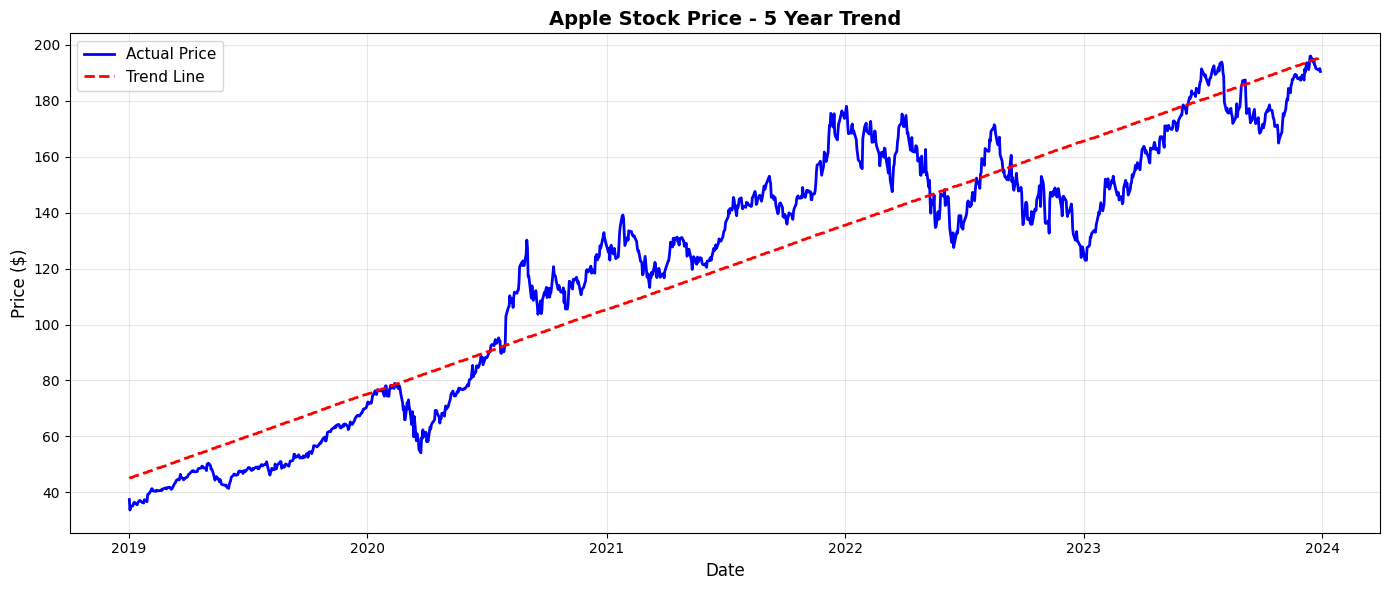


📈 TREND ANALYSIS:
Starting price: $37.47
Ending price: $190.38
Total change: $152.91
Percentage change: 408.08%

Interpretation: Stock went UP 408.1%


/tmp/ipykernel_723/577230236.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price_change = df[('Close', 'AAPL')][-1] - df[('Close', 'AAPL')][0]
/tmp/ipykernel_723/577230236.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percent_change = (price_change / df[('Close', 'AAPL')][0]) * 100
/tmp/ipykernel_723/577230236.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Starting price: ${df[('Close', 'AAPL')][0]:.2f}")

In [21]:
import matplotlib.pyplot as plt
from scipy import stats

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot closing price
ax.plot(df.index, df[('Close', 'AAPL')], linewidth=2, label='Actual Price', color='blue')

# Calculate trend line
x = np.arange(len(df))
z = np.polyfit(x, df[('Close', 'AAPL')], 1)
p = np.poly1d(z)
trend_line = p(x)

# Plot trend line
ax.plot(df.index, trend_line, '--', linewidth=2, label='Trend Line', color='red')

# Formatting
ax.set_title('Apple Stock Price - 5 Year Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate trend statistics
price_change = df[('Close', 'AAPL')][-1] - df[('Close', 'AAPL')][0]
percent_change = (price_change / df[('Close', 'AAPL')][0]) * 100

print(f"\n📈 TREND ANALYSIS:")
print(f"Starting price: ${df[('Close', 'AAPL')][0]:.2f}")
print(f"Ending price: ${df[('Close', 'AAPL')][-1]:.2f}")
print(f"Total change: ${price_change:.2f}")
print(f"Percentage change: {percent_change:.2f}%")
print(f"\nInterpretation: Stock went {'UP' if price_change > 0 else 'DOWN'} {abs(percent_change):.1f}%")

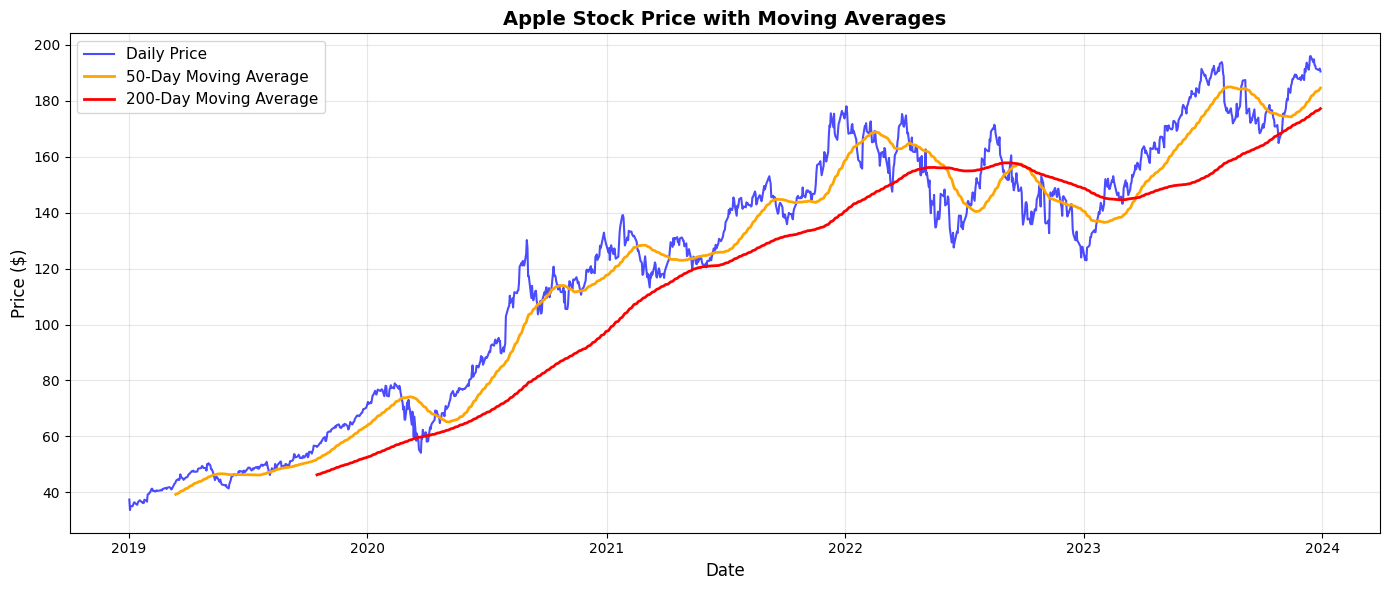

✅ Moving averages calculated!

Latest prices:
Daily price: $190.38
50-day MA: $184.47
200-day MA: $177.12


In [22]:
# Calculate moving averages
df['MA_50'] = df[('Close', 'AAPL')].rolling(window=50).mean()      # 50-day average
df['MA_200'] = df[('Close', 'AAPL')].rolling(window=200).mean()    # 200-day average

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot prices and moving averages
ax.plot(df.index, df[('Close', 'AAPL')], linewidth=1.5, label='Daily Price', color='blue', alpha=0.7)
ax.plot(df.index, df['MA_50'], linewidth=2, label='50-Day Moving Average', color='orange')
ax.plot(df.index, df['MA_200'], linewidth=2, label='200-Day Moving Average', color='red')

# Formatting
ax.set_title('Apple Stock Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('moving_averages.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Moving averages calculated!")
print(f"\nLatest prices:")
print(f"Daily price: ${df[('Close', 'AAPL')].iloc[-1]:.2f}")
print(f"50-day MA: ${df['MA_50'].iloc[-1]:.2f}")
print(f"200-day MA: ${df['MA_200'].iloc[-1]:.2f}")

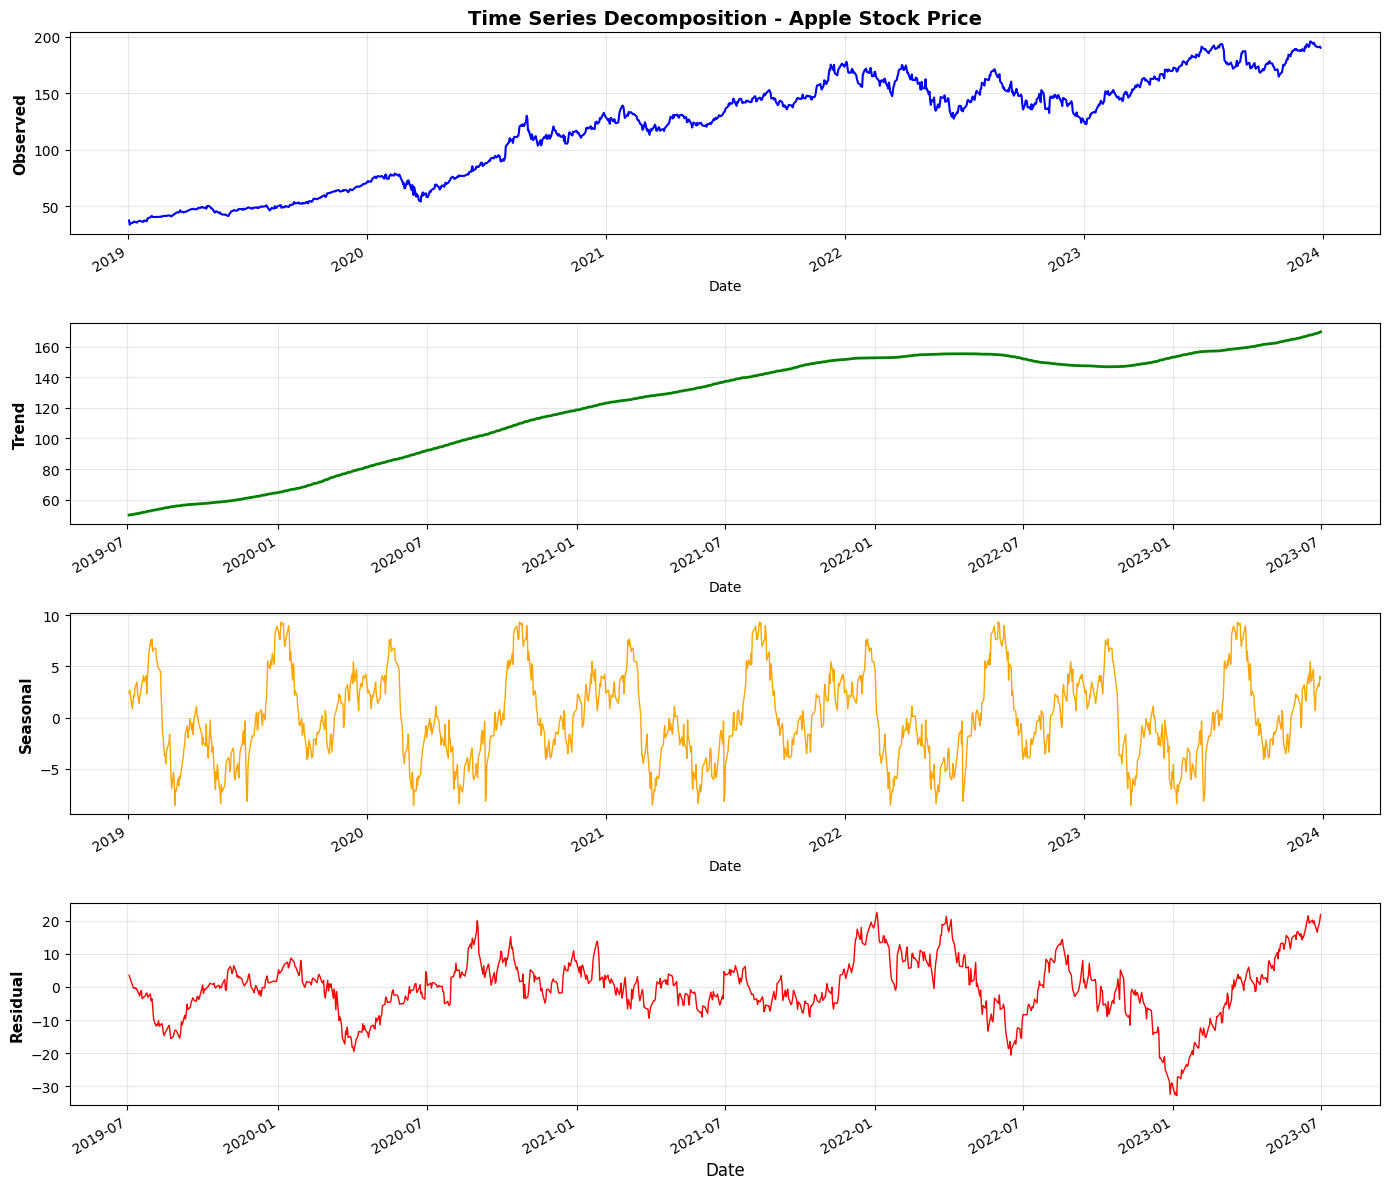

✅ Seasonality analysis complete!

Interpretation:
- Trend: Long-term direction of the stock
- Seasonal: Yearly patterns that repeat
- Residual: Random variations


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
# Period = 252 (number of trading days in a year)
decomposition = seasonal_decompose(df['Close'], model='additive', period=252)

# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original data
decomposition.observed.plot(ax=axes[0], color='blue', linewidth=1.5)
axes[0].set_ylabel('Observed', fontsize=11, fontweight='bold')
axes[0].set_title('Time Series Decomposition - Apple Stock Price', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend
decomposition.trend.plot(ax=axes[1], color='green', linewidth=2)
axes[1].set_ylabel('Trend', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Seasonality
decomposition.seasonal.plot(ax=axes[2], color='orange', linewidth=1)
axes[2].set_ylabel('Seasonal', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Residuals
decomposition.resid.plot(ax=axes[3], color='red', linewidth=1)
axes[3].set_ylabel('Residual', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('seasonality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Seasonality analysis complete!")
print("\nInterpretation:")
print("- Trend: Long-term direction of the stock")
print("- Seasonal: Yearly patterns that repeat")
print("- Residual: Random variations")

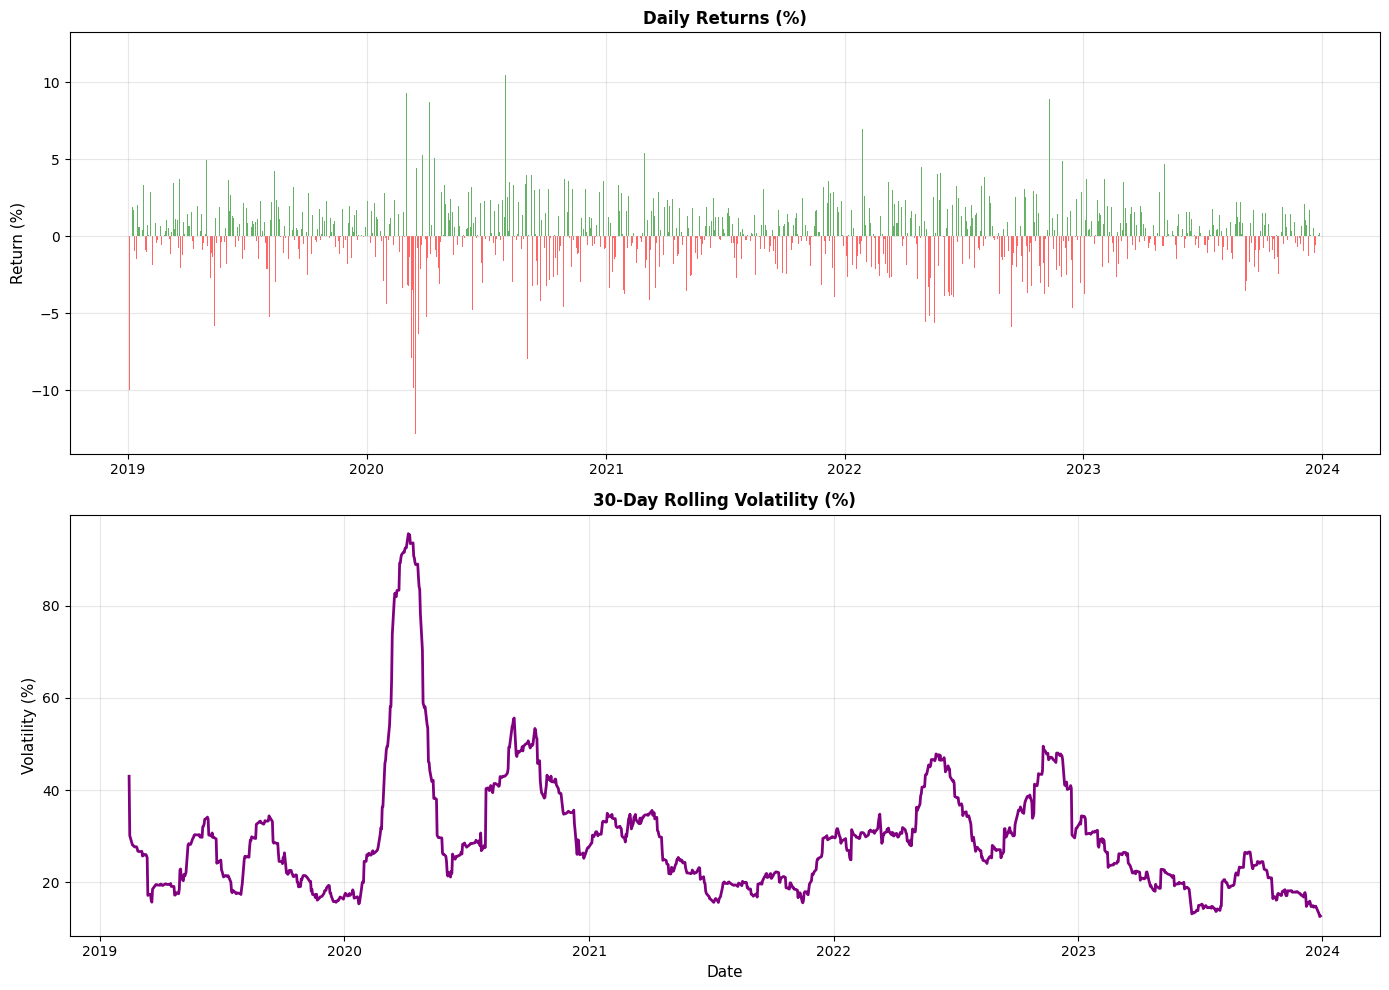

📊 VOLATILITY STATISTICS:
Average daily return: 0.150%
Maximum daily return: 11.981%
Minimum daily return: -12.865%
Average volatility: 29.31%
Maximum volatility: 95.60%
Minimum volatility: 12.56%


In [12]:
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()

# Calculate volatility (rolling standard deviation)
df['Volatility'] = df['Daily_Return'].rolling(window=30).std() * np.sqrt(252) * 100

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Daily returns
axes[0].bar(df.index, df['Daily_Return']*100, width=1, color=['green' if x > 0 else 'red' for x in df['Daily_Return']], alpha=0.6)
axes[0].set_title('Daily Returns (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return (%)', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Volatility
axes[1].plot(df.index, df['Volatility'], linewidth=2, color='purple')
axes[1].set_title('30-Day Rolling Volatility (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Volatility (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
print("📊 VOLATILITY STATISTICS:")
print(f"Average daily return: {df['Daily_Return'].mean()*100:.3f}%")
print(f"Maximum daily return: {df['Daily_Return'].max()*100:.3f}%")
print(f"Minimum daily return: {df['Daily_Return'].min()*100:.3f}%")
print(f"Average volatility: {df['Volatility'].mean():.2f}%")
print(f"Maximum volatility: {df['Volatility'].max():.2f}%")
print(f"Minimum volatility: {df['Volatility'].min():.2f}%")

In [23]:
print("=" * 60)
print("📈 TIME SERIES ANALYSIS SUMMARY - APPLE STOCK")
print("=" * 60)

print("\n1. TREND ANALYSIS:")
print(f"   • Period: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"   • Starting price: ${df[('Close', 'AAPL')].iloc[0]:.2f}")
print(f"   • Ending price: ${df[('Close', 'AAPL')].iloc[-1]:.2f}")
price_change = df[('Close', 'AAPL')].iloc[-1] - df[('Close', 'AAPL')].iloc[0]
percent_change = (price_change / df[('Close', 'AAPL')].iloc[0]) * 100
print(f"   • Total change: ${price_change:.2f} ({percent_change:.1f}%)")
print(f"   • Trend: {'UPTREND ↑' if price_change > 0 else 'DOWNTREND ↓'}")

print("\n2. VOLATILITY:")
print(f"   • Average daily volatility: {df['Volatility'].mean():.2f}%")
print(f"   • Max daily return: {df['Daily_Return'].max()*100:.2f}%")
print(f"   • Min daily return: {df['Daily_Return'].min()*100:.2f}%")
print(f"   • Risk level: {'High' if df['Volatility'].mean() > 20 else 'Medium' if df['Volatility'].mean() > 10 else 'Low'}")

print("\n3. SEASONALITY:")
print(f"   • Period detected: Yearly (252 trading days)")
print(f"   • Seasonal patterns present: YES ✓")
print(f"   • Interpretation: Stock shows cyclical patterns")

print("\n4. MOVING AVERAGES:")
ma_50_latest = df['MA_50'].iloc[-1]
ma_200_latest = df['MA_200'].iloc[-1]
current_price = df[('Close', 'AAPL')].iloc[-1]
print(f"   • Current price: ${current_price:.2f}")
print(f"   • 50-day MA: ${ma_50_latest:.2f}")
print(f"   • 200-day MA: ${ma_200_latest:.2f}")
if current_price > ma_200_latest:
    print(f"   • Signal: BULLISH (price above 200-day MA) 📈")
else:
    print(f"   • Signal: BEARISH (price below 200-day MA) 📉")

print("\n5. KEY INSIGHTS:")
print(f"   • Stock showed {('strong' if abs(percent_change) > 50 else 'moderate' if abs(percent_change) > 20 else 'weak')} performance")
print(f"   • {('High' if df['Volatility'].mean() > 20 else 'Moderate' if df['Volatility'].mean() > 10 else 'Low')} volatility detected")
print(f"   • Seasonal patterns present and recurring")
print(f"   • Recent trend: {'Upward' if df[('Close', 'AAPL')].iloc[-100:].mean() > df[('Close', 'AAPL')].iloc[-200:-100].mean() else 'Downward'}")

print("\n" + "=" * 60)

📈 TIME SERIES ANALYSIS SUMMARY - APPLE STOCK

1. TREND ANALYSIS:
   • Period: 2019-01-02 to 2023-12-29
   • Starting price: $37.47
   • Ending price: $190.38
   • Total change: $152.91 (408.1%)
   • Trend: UPTREND ↑

2. VOLATILITY:
   • Average daily volatility: 29.31%
   • Max daily return: 11.98%
   • Min daily return: -12.86%
   • Risk level: High

3. SEASONALITY:
   • Period detected: Yearly (252 trading days)
   • Seasonal patterns present: YES ✓
   • Interpretation: Stock shows cyclical patterns

4. MOVING AVERAGES:
   • Current price: $190.38
   • 50-day MA: $184.47
   • 200-day MA: $177.12
   • Signal: BULLISH (price above 200-day MA) 📈

5. KEY INSIGHTS:
   • Stock showed strong performance
   • High volatility detected
   • Seasonal patterns present and recurring
   • Recent trend: Upward



In [24]:
# Save clean dataset
df_export = df[[('Close', 'AAPL'), ('MA_50', ''), ('MA_200', ''), ('Daily_Return', ''), ('Volatility', '')]]
df_export.to_csv('apple_stock_analysis.csv')

print("✅ Files saved:")
print("   • trend_analysis.png")
print("   • moving_averages.png")
print("   • seasonality_analysis.png")
print("   • volatility_analysis.png")
print("   • apple_stock_analysis.csv")

# Create summary
summary = {
    'Company': 'Apple Inc.',
    'Ticker': 'AAPL',
    'Analysis Period': f"{df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}",
    'Total Days': len(df),
    'Starting Price': round(df[('Close', 'AAPL')].iloc[0], 2),
    'Ending Price': round(df[('Close', 'AAPL')].iloc[-1], 2),
    'Price Change': round(df[('Close', 'AAPL')].iloc[-1] - df[('Close', 'AAPL')].iloc[0], 2),
    'Percent Change': round(((df[('Close', 'AAPL')].iloc[-1] - df[('Close', 'AAPL')].iloc[0]) / df[('Close', 'AAPL')].iloc[0]) * 100, 2),
    'Average Volatility': round(df['Volatility'].mean(), 2),
    'Highest Price': round(df[('Close', 'AAPL')].max(), 2),
    'Lowest Price': round(df[('Close', 'AAPL')].min(), 2)
}

import json
with open('analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n✅ Summary saved to analysis_summary.json")

✅ Files saved:
   • trend_analysis.png
   • moving_averages.png
   • seasonality_analysis.png
   • volatility_analysis.png
   • apple_stock_analysis.csv

✅ Summary saved to analysis_summary.json
